In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [3]:
tf.__version__

'2.19.1'

In [4]:
# load dataset
max_features = 10000 # limit vocabulary to top 10,000 words
max_len = 500 # each review will be padded/truncated to 500 words

# load training and test sets with (reviews, labels)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

# pad the sequences so that each input has the same length (max_len)
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 17s 1us/step 


In [9]:
# build model
model = Sequential([
    # embedding layer converts each word index into a dense vector of fixed size (32)
    Embedding(max_features, 32),

    # SimpleRNN layer processes the sequence data and maintains a hidden state (memory) with 32 units
    SimpleRNN(32),

    # Dense output layer with a single neuron and sigmoid activation for binary classification
    Dense(1, activation="sigmoid")
])

# compile model
model.compile(optimizer="adam", # Adam optimizer for training
             loss="binary_crossentropy", # Binary cross-entropy loss for two classes (positive/negative)
             metrics=["accuracy"]) # Track accuracy metric during training

In [13]:
# train the model for 5 epochs with batch size of 64, using 20% of training data for validation
history = model.fit(x_train, y_train,
         epochs=10,
         batch_size=64,
         validation_split=0.2)

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.8072 - loss: 0.4217 - val_accuracy: 0.8090 - val_loss: 0.4915
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 109ms/step - accuracy: 0.9289 - loss: 0.1865 - val_accuracy: 0.8120 - val_loss: 0.4670
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.9556 - loss: 0.1354 - val_accuracy: 0.8276 - val_loss: 0.4686
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - accuracy: 0.9692 - loss: 0.0971 - val_accuracy: 0.8168 - val_loss: 0.5290
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 33s 104ms/step - accuracy: 0.9784 - loss: 0.0716 - val_accuracy: 0.8132 - val_loss: 0.6092
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 112ms/step - accuracy: 0.9864 - loss: 0.0484 - val_accuracy: 0.8082 - val_loss: 0.6689
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 34s 108ms/step - accuracy: 0.9896 - loss: 0.0427 - val_accuracy: 0.8210 - val_loss: 0.6758
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 36s 114ms/step - accuracy: 0.9931 - loss: 0.

In [11]:
# evaluate model
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.6476 - loss: 0.6252
Test Accuracy: 0.65


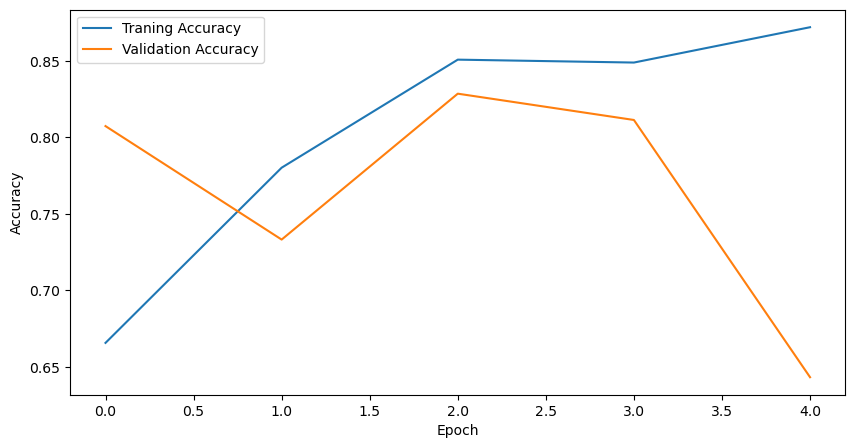

In [12]:
import matplotlib.pyplot as plt

# plot training history
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Traning Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()